# Optical Flow on `.cine` Video

This notebook loads a Phantom `.cine` video, computes optical flow, and visualizes the result.

Supported backends through `compute_optical_flows(...)`:

- `"auto"`: prefer `nvidia_hw` for CuPy float input, otherwise use `farneback`
- `"farneback"`: OpenCV Farneback
- `"nvidia_hw"`: NVIDIA Optical Flow SDK hardware backend
- `"raft"`: RAFT deep model

To change the backend, edit the `BACKEND = ...` line in the configuration cell.

In [144]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if not (repo_root / "OSCC_postprocessing").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(repo_root)

C:\Users\Jiang\Documents\Mie_Py\Mie_Postprocessing_Py


## Configuration

Set the `.cine` path and backend here.

For `BACKEND = "nvidia_hw"`:
- the bridge must already be built
- CuPy must be installed
- input will be converted to `cupy.float32`

For `BACKEND = "farneback"`:
- CPU path
- easiest to run

For `BACKEND = "raft"`:
- RAFT repo + weights must already be available

In [145]:
CINE_PATH = Path(r"G:\MeOH_test\Schlieren\T56_Schlieren Cam_1.cine")

FRAME_LIMIT = 100
PAIR_INDEX = 75
BACKEND = "raft"  # change to: "farneback", "nvidia_hw", "raft"

# Optional crop to speed up testing
ROW_SLICE = slice(None)
COL_SLICE = slice(None)

# Backend-specific kwargs
BACKEND_KWARGS = {
    # "grid_size": 1,      # mainly used by nvidia_hw
    # "preset": "slow", # mainly used by nvidia_hw
    # "levels": 5,         # mainly used by farneback
    # "winsize": 15,       # mainly used by farneback
}

assert CINE_PATH.exists(), f"File not found: {CINE_PATH}"

In [146]:
import numpy as np
import matplotlib.pyplot as plt

from OSCC_postprocessing.cine.functions_videos import load_cine_video
from OSCC_postprocessing.motion import compute_optical_flows

try:
    import cupy as cp
except Exception:
    cp = None

plt.rcParams["figure.figsize"] = (8, 6)

## Load `.cine` video

Video Info - Width: 768, Height: 768, Frames: 100
video shape: (100, 768, 768) dtype: uint16


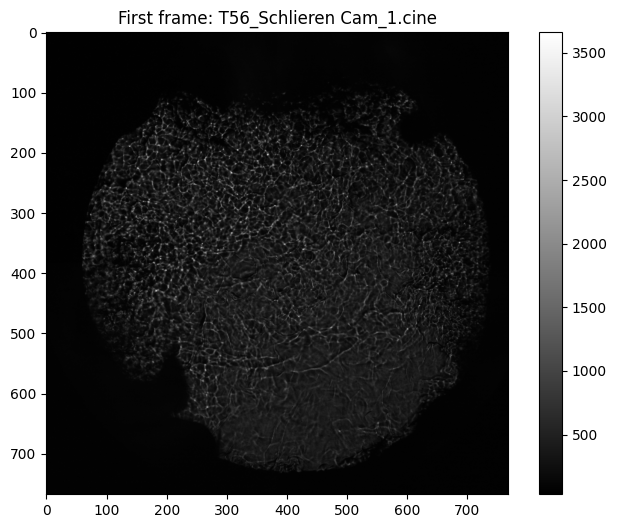

In [147]:

video = load_cine_video(str(CINE_PATH), frame_limit=FRAME_LIMIT)
video = video[:, ROW_SLICE, COL_SLICE]



video = video.astype(np.uint16)
print("video shape:", video.shape, "dtype:", video.dtype)

frame0 = video[0].astype(np.float16)
plt.imshow(frame0, cmap="gray")
plt.title(f"First frame: {CINE_PATH.name}")
plt.colorbar()
plt.show()

## Prepare input for the selected backend

- `nvidia_hw` expects CuPy float input
- `farneback` and `raft` can use NumPy input directly

In [148]:
if BACKEND == "nvidia_hw":
    if cp is None:
        raise ImportError("CuPy is required for BACKEND='nvidia_hw'")
    video_input = cp.asarray(video, dtype=cp.float32)
else:
    video_input = video.astype(np.float32, copy=False)

type(video_input), getattr(video_input, "dtype", None)

(numpy.ndarray, dtype('float32'))

## Compute optical flow

In [149]:
import time

t0 = time.time()
flows = compute_optical_flows(
    video_input,
    backend=BACKEND,
    out_hw_last=True,
    **BACKEND_KWARGS,
)
elapsed = time.time() - t0

if cp is not None and isinstance(flows, cp.ndarray):
    flows_np = cp.asnumpy(flows)
else:
    flows_np = np.asarray(flows)

print("backend:", BACKEND)
print("flow shape:", flows_np.shape)
print("flow dtype:", flows_np.dtype)
print(f"elapsed: {elapsed:.3f} s")

backend: raft
flow shape: (99, 768, 768, 2)
flow dtype: float32
elapsed: 21.545 s


## Flow helpers

In [150]:
import cv2

def flow_to_rgb(flow_hw2: np.ndarray, clip_mag: float | None = None) -> np.ndarray:
    fx = flow_hw2[..., 0]
    fy = flow_hw2[..., 1]
    mag, ang = cv2.cartToPolar(fx.astype(np.float32), fy.astype(np.float32), angleInDegrees=False)
    if clip_mag is None:
        clip_mag = float(np.percentile(mag, 99)) if mag.size else 1.0
    clip_mag = max(clip_mag, 1e-6)
    hsv = np.zeros(flow_hw2.shape[:2] + (3,), dtype=np.uint8)
    hsv[..., 0] = np.mod(ang * 180 / np.pi / 2, 180).astype(np.uint8)
    hsv[..., 1] = 255
    hsv[..., 2] = np.clip(mag / clip_mag * 255, 0, 255).astype(np.uint8)
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

def flow_magnitude(flow_hw2: np.ndarray) -> np.ndarray:
    return np.linalg.norm(flow_hw2, axis=-1)


## Visualize one frame pair

Change `PAIR_INDEX` to inspect another pair.

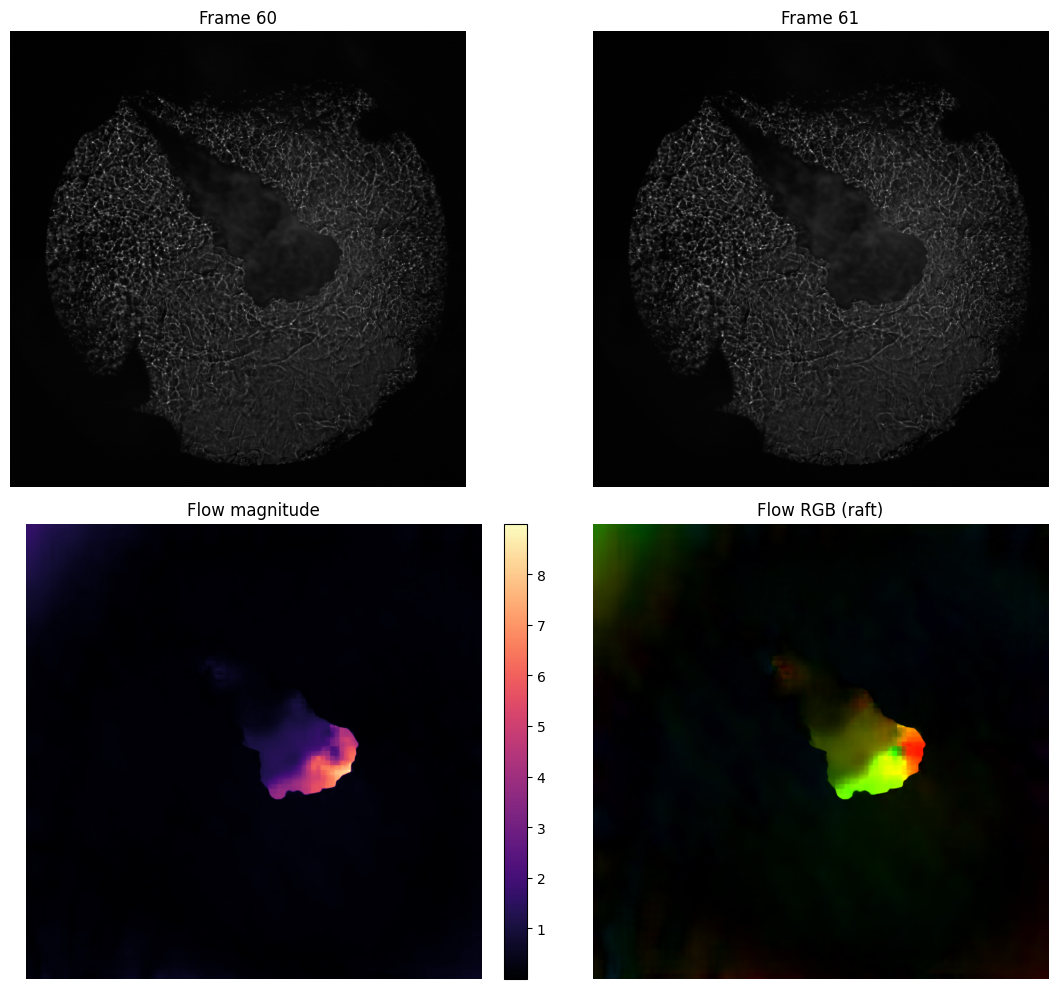

In [158]:


frame_a = video[PAIR_INDEX].astype(np.float32)
frame_b = video[PAIR_INDEX + 1].astype(np.float32)
flow = flows_np[PAIR_INDEX]
mag = flow_magnitude(flow)
rgb = flow_to_rgb(flow)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(frame_a, cmap="gray")
axes[0, 0].set_title(f"Frame {PAIR_INDEX}")
axes[0, 1].imshow(frame_b, cmap="gray")
axes[0, 1].set_title(f"Frame {PAIR_INDEX + 1}")
im = axes[1, 0].imshow(mag, cmap="magma")
axes[1, 0].set_title("Flow magnitude")
plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
axes[1, 1].imshow(rgb)
axes[1, 1].set_title(f"Flow RGB ({BACKEND})")

for ax in axes.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()

## Quiver overlay

Use a stride so the arrows stay readable.

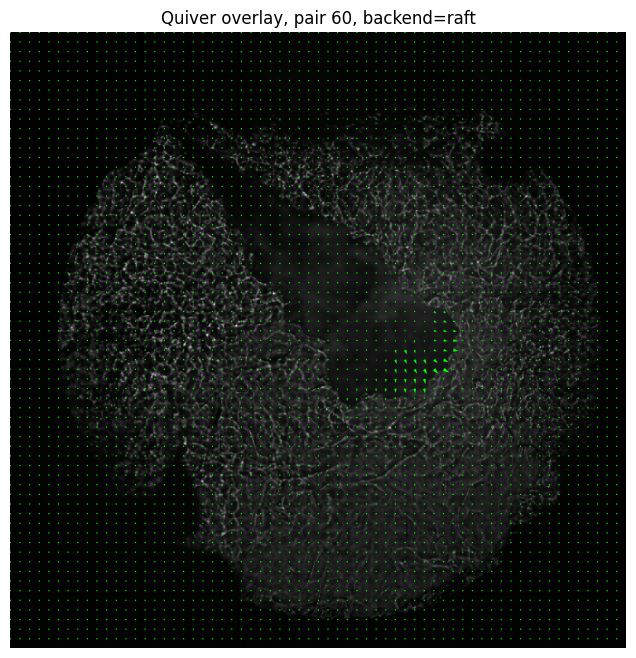

In [159]:
QUIVER_STRIDE = 12

h, w = flow.shape[:2]
yy, xx = np.mgrid[0:h:QUIVER_STRIDE, 0:w:QUIVER_STRIDE]
uu = flow[::QUIVER_STRIDE, ::QUIVER_STRIDE, 0]
vv = flow[::QUIVER_STRIDE, ::QUIVER_STRIDE, 1]

plt.figure(figsize=(10, 8))
plt.imshow(frame_a, cmap="gray")
plt.quiver(xx, yy, uu, vv, color="lime", angles="xy", scale_units="xy", scale=1)
plt.title(f"Quiver overlay, pair {PAIR_INDEX}, backend={BACKEND}")
plt.axis("off")
plt.show()

## Quick summary over time

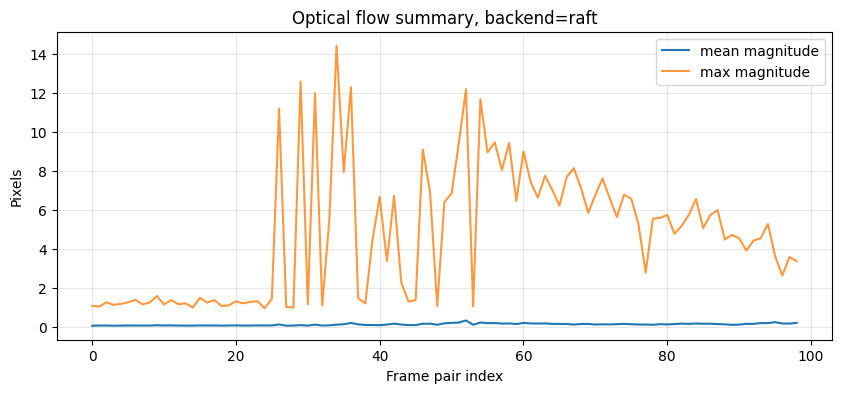

In [160]:
magnitudes = np.linalg.norm(flows_np, axis=-1)
mean_mag = magnitudes.mean(axis=(1, 2))
max_mag = magnitudes.max(axis=(1, 2))

plt.figure(figsize=(10, 4))
plt.plot(mean_mag, label="mean magnitude")
plt.plot(max_mag, label="max magnitude", alpha=0.8)
plt.xlabel("Frame pair index")
plt.ylabel("Pixels")
plt.title(f"Optical flow summary, backend={BACKEND}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [161]:
F, H, W = video.shape

flow_gray = np.empty((F-1, H, W))

for f in range(FRAME_LIMIT-1):
    flow_gray[f] = flow_magnitude(flows_np[f])

In [162]:
def _min_max_scale(arr):
    mn = arr.min()
    mx = arr.max()
    if mx > mn:
        return (arr - mn) / (mx - mn)
    return np.zeros_like(arr)

In [163]:
from OSCC_postprocessing.playback.video_playback import *
play_video_cv2(_min_max_scale(flow_gray))